### Import Dependencies

In [2]:
import numpy as np
import pandas as pd 
import matplotlib.pyplot as plt 
import seaborn as sns

### Loading data

In [3]:
data_file_path = "../data/raw_data.csv"
data_matrix = pd.read_csv(data_file_path)

### Deleting Persons with Tenure = 0

In [4]:
data_matrix = data_matrix[data_matrix["tenure"]>0]

In [5]:
data_matrix['TotalCharges'] = data_matrix['TotalCharges'].replace(' ', np.nan)
data_matrix['TotalCharges'] = pd.to_numeric(data_matrix['TotalCharges'], errors='coerce')
print(data_matrix.isna().sum())

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64


### Converting the Binary non-numerical Columns into numerical Columns

In [6]:
binary_columns = ["Partner", "Dependents", "PhoneService", "PaperlessBilling","Churn"]
for column in binary_columns:
    data_matrix[column] = (data_matrix[column]=="Yes").astype(int)


data_matrix["gender"] = (data_matrix["gender"]=="Male").astype(int)



### For categorical columns with more than two option we will apply One-Hot Encoding

In [7]:
multi_categ_columns = ["StreamingMovies","MultipleLines","InternetService", "OnlineSecurity","OnlineBackup", "DeviceProtection","TechSupport","StreamingTV","Contract","PaymentMethod"]

data_matrix = pd.get_dummies(data_matrix,columns=multi_categ_columns,drop_first=True, dtype = int)


### Correlation Matrix

In [8]:
churn_corr = data_matrix.corrwith(data_matrix["Churn"], numeric_only=True)

absolute_churn_corr = churn_corr.drop("Churn").abs().sort_values(ascending=False)

absolute_churn_corr

tenure                                   0.354049
InternetService_Fiber optic              0.307463
Contract_Two year                        0.301552
PaymentMethod_Electronic check           0.301455
OnlineSecurity_No internet service       0.227578
DeviceProtection_No internet service     0.227578
StreamingTV_No internet service          0.227578
StreamingMovies_No internet service      0.227578
TechSupport_No internet service          0.227578
InternetService_No                       0.227578
OnlineBackup_No internet service         0.227578
TotalCharges                             0.199484
MonthlyCharges                           0.192858
PaperlessBilling                         0.191454
Contract_One year                        0.178225
OnlineSecurity_Yes                       0.171270
TechSupport_Yes                          0.164716
Dependents                               0.163128
SeniorCitizen                            0.150541
Partner                                  0.149982


### Ploting also the heatmap

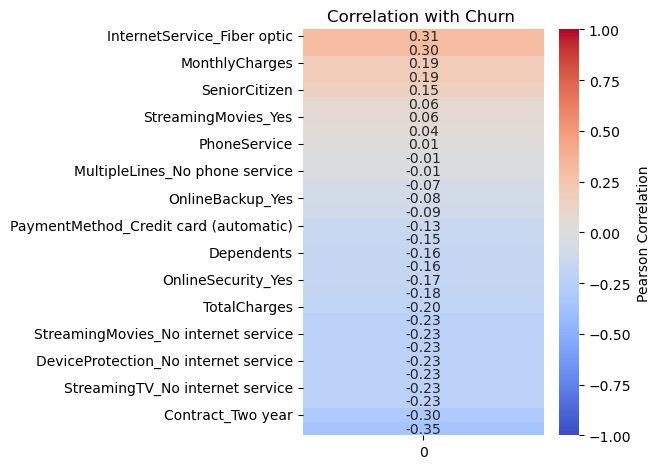

In [13]:

sorted_corr = churn_corr.drop("Churn").sort_values(ascending=False).to_frame()


sns.heatmap(
    sorted_corr,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    vmin=-1,
    vmax=1,
    cbar_kws={"label": "Pearson Correlation"},
)

plt.title("Correlation with Churn ")
plt.tight_layout()
plt.show()

### Removing useless columns (Columns with correlation value smaller than 0.08) I chose to keep some columns with small corelation for the Random Forest Model

In [ ]:
bad_columns = ["DeviceProtection_Yes","StreamingTV_Yes","StreamingMovies_Yes","MultipleLines_Yes","MultipleLines_No phone service","PhoneService","gender"]
data_matrix = data_matrix.drop(columns=bad_columns)

### Removing the customerID column (it is not relevant)

In [ ]:
data_matrix = data_matrix.drop(columns = ["customerID"])

data_matrix

,SeniorCitizen,Partner,Dependents,tenure,PaperlessBilling,MonthlyCharges,TotalCharges,Churn,StreamingMovies_No internet service,InternetService_Fiber optic,...,OnlineBackup_Yes,DeviceProtection_No internet service,TechSupport_No internet service,TechSupport_Yes,StreamingTV_No internet service,Contract_One year,Contract_Two year,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,0,1,0,1,1,29.85,29.85,0,0,0,...,1,0,0,0,0,0,0,0,1,0
1,0,0,0,34,0,56.95,1889.50,0,0,0,...,0,0,0,0,0,1,0,0,0,1
2,0,0,0,2,1,53.85,108.15,1,0,0,...,1,0,0,0,0,0,0,0,0,1
3,0,0,0,45,0,42.30,1840.75,0,0,0,...,0,0,0,1,0,1,0,0,0,0
4,0,0,0,2,1,70.70,151.65,1,0,1,...,0,0,0,0,0,0,0,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,0,1,1,24,1,84.80,1990.50,0,0,0,...,0,0,0,1,0,1,0,0,0,1
7039,0,1,1,72,1,103.20,7362.90,0,0,1,...,1,0,0,0,0,1,0,1,0,0
7040,0,1,1,11,1,29.60,346.45,0,0,0,...,0,0,0,0,0,0,0,0,1,0
7041,1,1,0,4,1,74.40,306.60,1,0,1,...,0,0,0,0,0,0,0,0,0,1


## Feature Engineering

In [ ]:
data_matrix["inscreseas"] = (data_matrix["TotalCharges"] / data_matrix["tenure"] < data_matrix["MonthlyCharges"]).astype(int)

### Exporting the processed data

In [ ]:
data_matrix.to_csv("../data/processed_data.csv", index=False)